# Trabajo de migración de la lista del SII

Puntos:
1. Se impoportan la base
2. Se importan los datos
3. Se dejan solo empresas que estén funcionando
4. Se dejan empresas con más de {} trabajadores
5. Se deja en un CSV

In [84]:
# Instalar dependencias si no están disponibles
import importlib, subprocess, sys
import pandas as pd
sys.path.insert(0, "/Users/juanpablozepeda/Proyecto Plutto /Scoring")
import Scoring_ICP
importlib.reload(Scoring_ICP)
from Scoring_ICP import get_company_data
sys.path.insert(0, "/Users/juanpablozepeda/Proyecto Plutto /Holding_asker")
import Holding_Asker
importlib.reload(Holding_Asker)
from Holding_Asker import get_hijos, get_padres

def ensure(pkg, import_name=None):
    name = import_name or pkg
    if importlib.util.find_spec(name) is None:
        print(f"Instalando {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
        print(f"{pkg} instalado.")
    else:
        print(f"{pkg} ya disponible.")


def obtener_num_addresses(rut):
    try:
        data = get_company_data(rut)
        return data["num_addresses"]
    except Exception as e:
        print(f"  Error RUT {rut}: {e}")
        return None
    
def obtener_hijos(rut):
    try:
        return get_hijos(rut)["count"]
    except Exception as e:
        print(f"  Error hijos {rut}: {e}")
        return None

def obtener_padres(rut):
    try:
        return get_padres(rut)["count"]
    except Exception as e:
        print(f"  Error padres {rut}: {e}")
        return None

ensure("anthropic")
ensure("pandas")

anthropic ya disponible.
pandas ya disponible.


In [85]:
# Empresas personas jurídicas 2024
df_empresas = pd.read_csv(
    "/Users/juanpablozepeda/Proyecto Plutto /Sii folder/PUB_EMPRESAS_PJ_2024.txt",
    sep="\t",
    encoding="utf-8",
    dtype={"RUT": str, "DV": str},
)
# print(f"Empresas PJ — Filas: {len(df_empresas):,}")
# print(f"Columnas: {list(df_empresas.columns)}")

KeyboardInterrupt: 

In [ ]:
# Filtrar empresas sin fecha de término de giro

df_funcionando = df_empresas[df_empresas["Fecha término de giro"].isna()].copy()

print(f"Sin termino de giro:    {len(df_funcionando):,}")
print(f"con término de giro:    {df_empresas['Fecha término de giro'].notna().sum():,}")
print(f"Total:                  {len(df_empresas):,}")

#df_funcionando[["RUT","DV", "Razón social",'Número de trabajadores dependie',  "Tramo según ventas", "Rubro económico", "Actividad económica", "Región", "Provincia"]].head(20)

Sin termino de giro:    978,601
con término de giro:    15,875
Total:                  994,476


In [ ]:
# Construcción del DF final con columnas seleccionadas

# Unir RUT + DV en formato "RUT-DV"
df_funcionando["RUT_DV"] = df_funcionando["RUT"].str.strip() + "-" + df_funcionando["DV"].str.strip()

# Detectar nombre exacto de "Número de trabajadores" (puede estar truncado)
col_trabajadores = next((c for c in df_funcionando.columns if "trabajadores" in c.lower()), None)

# Detectar nombre exacto de "Tipo de contribuyente"
col_tipo = next((c for c in df_funcionando.columns if "tipo" in c.lower() and "contribuy" in c.lower()), None)

print(f"Col trabajadores → {col_trabajadores}")
print(f"Col tipo de contribuyente → {col_tipo}")

# Columnas a mantener (en orden)
cols_finales = ["RUT_DV", "Razón social", "Tramo según ventas", col_trabajadores, col_tipo, "Actividad económica", "Región"]
cols_finales = [c for c in cols_finales if c is not None]  # eliminar None si no existe la columna

df_final = df_funcionando[cols_finales].copy()

# Renombrar para mayor claridad
rename_map = {
    col_trabajadores: "Número de trabajadores",
}
if col_tipo:
    rename_map[col_tipo] = "Tipo de contribuyente"

df_final = df_final.rename(columns=rename_map)

print(f"\nFilas: {len(df_final):,}")
print(f"Columnas: {list(df_final.columns)}")

df_final.head(2)

Col trabajadores → Número de trabajadores dependie
Col tipo de contribuyente → Tipo de contribuyente

Filas: 978,601
Columnas: ['RUT_DV', 'Razón social', 'Tramo según ventas', 'Número de trabajadores', 'Tipo de contribuyente', 'Actividad económica', 'Región']


,RUT_DV,Razón social,Tramo según ventas,Número de trabajadores,Tipo de contribuyente,Actividad económica,Región
0,50000100-3,FUNDACION ARTURO IRARRAZAVAL CORREA,1,5,SIN PER. JURIDICA,OTRAS ACTIVIDADES DE ATENCION EN INSTITUCIONES,XIII REGION METROPOLITANA
1,50000510-6,TORREJON CASTRO LUIS Y JOSE,1,0,SIN PER. JURIDICA,TRANSPORTE DE CARGA POR CARRETERA,IV REGION COQUIMBO


In [ ]:
# Empresas con tramo según ventas > 7 (pequeñas, medianas, grandes y muy grandes)

df_grandes = df_final[df_final["Tramo según ventas"] > 7].copy()

print(f"Empresas con tramo > 7: {len(df_grandes):,}")
print(df_grandes["Tramo según ventas"].value_counts().sort_index())


Empresas con tramo > 7: 53,148
Tramo según ventas
8     22402
9     13157
10     7536
11     6074
12     1371
13     2608
Name: count, dtype: int64


In [ ]:
#Emrpesas que tienen más de Min_Workers fundionando

min_workers = 10

df_funcionando_workers = df_grandes[df_grandes["Número de trabajadores"] > min_workers].copy()

print(f"Empresas que tinen más de {min_workers} trabajadores: {len(df_funcionando_workers):,}")

Empresas que tinen más de 10 trabajadores: 33,437


In [ ]:
# Segmentación:

# Palabras claves 

SEGMENTOS = {
    "Mining / Energía": [
        "mina", "miner", "cantera", "extrac", "petroleo", "carbon de piedra",
        "cobre", "litio", "hierro", "zinc", "plomo", "mangane", "uranio",
        "plata", "oro", "gas natural", "refinacion del petroleo",
        "generacion de energia", "transmision de energia", "distribucion de energia",
        "generacion, transmision", "gasoducto", "oleoducto", "regasificacion",
        "extraccion de sal", "turba", "carbon vegetal",
        "apoyo para la extraccion", "apoyo para la explotacion de otras minas",
        "explotacion de minas",
    ],
    "Financiero": [
        "bancar", "bancaria", "intermediacion monetaria", "leasing financiero",
        "factoring", "financiera", "financiero", "corredores de bolsa",
        "agentes de valores", "fondo de inversion", "fondos de inversion",
        "fondo mutuo", "administradoras de fondos", "sociedad de cartera",
        "sociedades de cartera", "seguro de vida", "seguros generales", "reaseguro",
        "isapre", "afp", "casas de cambio", "camara de compensacion",
        "credito prendario", "clasificadora de riesgo", "securitizadora",
        "cajas de compensacion", "agencias de calificacion crediticia",
        "agencias de cobro", "administracion de tarjetas", "administracion de mercados financieros",
        "otras actividades de servicios financieros",
        "otras actividades auxiliares de las actividades de servicios financieros",
        "otras actividades auxiliares de las actividades de seguros",
        "otras actividades de concesion de credito",
        "fondos y sociedades de inversion",
        "asesoria y gestion en la compra o venta de pequeñas y medianas empresas",
        "empresas de asesoria y consultoria en inversion financiera",
        "evaluacion de riesgos y daños",
    ],
    "Utilities / Infraestructura": [
        "suministro de agua", "captacion, tratamiento y distribucion de agua",
        "evacuacion de aguas", "aguas servidas", "aguas residuales",
        "suministro de electricidad", "distribucion de energia electrica",
        "transmision de energia electrica", "generacion de energia electrica",
        "fabricacion de gas", "distribucion de combustibles gaseosos",
        "suministro de vapor",
        "transporte de carga", "transporte de pasajeros", "transporte maritimo",
        "transporte interurbano", "transporte urbano", "transporte suburbano",
        "transporte por ferrocarril", "transporte por gasoducto", "transporte por oleoducto",
        "transporte por tuberias", "transporte por vias de navegacion",
        "transporte de carga maritimo", "servicios prestados por concesionarios de carreteras",
        "manipulacion de la carga", "almacenamiento y deposito",
        "explotacion de terminales terrestres",
        "telefonia", "telecomunicaciones", "television de pago", "transmisiones de radio",
        "programacion y transmisiones de television", "radiocomunicaciones",
        "portales web", "procesamiento de datos",
        "servicios vinculadas al transporte aereo", "servicios vinculadas al transporte acuatico",
        "agencias de naves",
        "concesionaria", "aeropuerto",             
        "servicios profesionales de ingenieria",    
        "ingenieria y construccion",
    ],
    "Manufactura / Retail": [
        "fabricacion de", "industrias basicas", "fundicion", "forja",
        "elaboracion de", "elaboracion y conservacion",
        "construccion de edificios", "construccion de carreteras",
        "construccion de otras obras", "construccion de proyectos",
        "construccion de buques", "terminacion y acabado de edificios",
        "demolicion", "preparacion del terreno", "instalaciones electricas",
        "instalaciones de gasfiteria", "otras instalaciones para obras",
        "otras actividades especializadas de construccion",
        "aserrado y acepilladura", "curtido y adobo",
        "venta al por menor en comercios de alimentos",
        "venta al por menor en comercios de vestuario",
        "venta al por mayor de alimentos", "venta al por mayor de bebidas",
        "venta al por mayor de carne",
        "mantenimiento y reparacion de vehiculos automotores",
        "venta de vehiculos automotores", "venta al por mayor de vehiculos",
        "fabricacion de vehiculos", "fabricacion de partes, piezas y accesorios para vehiculos",
        "fabricacion de carrocerias",
        "otras industrias manufactureras",
        "impresion", "reproduccion de grabaciones",
        "tratamiento y revestimiento de metales",
        "pesca", "acuicultura",
        "cultivo y crianza de peces", "cultivo de peces", "crianza de peces",
        "productos del mar", "conservacion de pescado",
        "elaboracion y conservacion de pescado",
        "elaboracion y conservacion de crustaceos",
        "procesamiento de pescado", "harina de pescado", "aceite de pescado",
    ],
}

def clasificar(actividad: str) -> str | None:
    a = actividad.lower()
    for segmento, keywords in SEGMENTOS.items():
        for kw in keywords:
            if kw in a:
                return segmento
    return None



# ── 3. Aplicar clasificación ──────────────────────────────────────────────────
df_funcionando_workers["Segmento"] = df_funcionando_workers["Actividad económica"].apply(clasificar)

#df_funcionando.head()

In [ ]:
#Dejo solo los segmentados

df_segmentado = df_funcionando_workers[df_funcionando_workers["Segmento"].notna()].copy()

print(f"Empresas que tienen un segmento buscado: {len(df_segmentado):,}")

print(df_segmentado["Segmento"].value_counts().sort_index())

pd.crosstab(
    df_segmentado["Tramo según ventas"],
    df_segmentado["Segmento"],
    margins=True,
    margins_name="Total"
)
df_segmentado.head(2)



Empresas que tienen un segmento buscado: 12,428
Segmento
Financiero                      790
Manufactura / Retail           7383
Mining / Energía               1490
Utilities / Infraestructura    2765
Name: count, dtype: int64


,RUT_DV,Razón social,Tramo según ventas,Número de trabajadores,Tipo de contribuyente,Actividad económica,Región,Segmento
72,50075620-9,COMERCIAL EBERLEIN SPA,9,48,SIN PER. JURIDICA,MANTENIMIENTO Y REPARACION DE VEHICULOS AUTOMO...,V REGION VALPARAISO,Manufactura / Retail
111,50112960-7,JURE ESGUEP LTDA,8,38,SIN PER. JURIDICA,"FABRICACION DE CUERDAS, CORDELES, BRAMANTES Y ...",XIII REGION METROPOLITANA,Manufactura / Retail


In [ ]:
# Le aplico los otros cambos necesarios a las empresas segmentadas

# #df_segmentado["num_addresses"] = df_segmentado["RUT_DV"].apply(obtener_num_addresses)
# df_segmentado["num_hijos"] = df_segmentado["RUT_DV"].apply(obtener_hijos)
# df_segmentado["num_padres"] = df_segmentado["RUT_DV"].apply(obtener_padres)

# df_segmentado.head(2)


# Aplicación del Scoring

In [ ]:
# ── Pasos 7-8: Agregar atributo Scored y guardar CSV ─────────────────────────
import os
import pandas as pd

CSV_PATH = "/Users/juanpablozepeda/Proyecto Plutto /Sii folder/Empresas_SII_Scored.csv"

if os.path.exists(CSV_PATH):
    df_sii_scored = pd.read_csv(CSV_PATH)
    ya_scoreadas = int(df_sii_scored["Scored"].sum())
    print(f"CSV existente cargado: {len(df_sii_scored):,} empresas | {ya_scoreadas} ya scoreadas | {len(df_sii_scored) - ya_scoreadas} pendientes")
else:
    df_sii_scored = df_segmentado.copy()
    df_sii_scored["Scored"]     = False
    df_sii_scored["score"]      = None
    df_sii_scored["vertical"]   = None
    df_sii_scored["pain_point"] = None
    df_sii_scored["reasoning"]  = None
    df_sii_scored["num_hijos"]  = None
    df_sii_scored["num_padres"] = None
    df_sii_scored.to_csv(CSV_PATH, index=False, encoding="utf-8")
    print(f"CSV creado: {len(df_sii_scored):,} empresas → {CSV_PATH}")

df_sii_scored.head(2)


CSV creado: 12,428 empresas → /Users/juanpablozepeda/Proyecto Plutto /Sii folder/Empresas_SII_Scored.csv


,RUT_DV,Razón social,Tramo según ventas,Número de trabajadores,Tipo de contribuyente,Actividad económica,Región,Segmento,Scored,score,vertical,pain_point,reasoning,num_hijos,num_padres
72,50075620-9,COMERCIAL EBERLEIN SPA,9,48,SIN PER. JURIDICA,MANTENIMIENTO Y REPARACION DE VEHICULOS AUTOMO...,V REGION VALPARAISO,Manufactura / Retail,False,None,None,None,None,None,None
111,50112960-7,JURE ESGUEP LTDA,8,38,SIN PER. JURIDICA,"FABRICACION DE CUERDAS, CORDELES, BRAMANTES Y ...",XIII REGION METROPOLITANA,Manufactura / Retail,False,None,None,None,None,None,None


In [ ]:
# ── Pasos 9-10: Scorear primeras N empresas no scoreadas y actualizar CSV ─────
import sys, importlib, time
sys.path.insert(0, "/Users/juanpablozepeda/Proyecto Plutto /Scoring")
import Scoring_ICP
importlib.reload(Scoring_ICP)
from Scoring_ICP import score_lead_adj2
sys.path.insert(0, "/Users/juanpablozepeda/Proyecto Plutto /Holding_asker")
import Holding_Asker
importlib.reload(Holding_Asker)
from Holding_Asker import get_hijos, get_padres

N_BATCH = 100  # Cuántas empresas scorear en esta ejecución


def aplicar_score_batch(csv_path: str, n: int = 10):
    df = pd.read_csv(csv_path)

    # Asegurar dtype correcto para columnas de texto
    for col in ["vertical", "pain_point", "reasoning"]:
        df[col] = df[col].astype(object)

    pendientes = df[df["Scored"] == False]

    if pendientes.empty:
        print("✅ Todas las empresas ya fueron scoreadas.")
        return df

    lote = pendientes.head(n)
    print(f"Procesando {len(lote)} empresas ({len(pendientes)} pendientes en total)...\n")

    for idx, row in lote.iterrows():
        rut    = row["RUT_DV"]
        nombre = row["Razón social"] if pd.notna(row["Razón social"]) else f"RUT {rut}"

        num_hijos  = row["num_hijos"]
        num_padres = row["num_padres"]

        if pd.isna(num_hijos):
            try:
                num_hijos = get_hijos(rut)["count"]
            except Exception:
                num_hijos = 0

        if pd.isna(num_padres):
            try:
                num_padres = get_padres(rut)["count"]
            except Exception:
                num_padres = 0

        try:
            resultado = score_lead_adj2(
                company_name     = str(nombre),
                rut              = str(rut),
                giro             = str(row["Segmento"]),
                tramo            = str(row["Tramo según ventas"]),
                region           = str(row["Región"]),
                num_hijos        = str(int(num_hijos)),
                num_trabajadores = str(int(row.get("Número de trabajadores") or 0)),
                num_padres       = str(int(num_padres)),
            )

            df.at[idx, "Scored"]     = True
            df.at[idx, "score"]      = resultado["score"]
            df.at[idx, "vertical"]   = resultado["vertical"]
            df.at[idx, "pain_point"] = resultado["pain_point"]
            df.at[idx, "reasoning"]  = resultado["reasoning"]
            df.at[idx, "num_hijos"]  = num_hijos
            df.at[idx, "num_padres"] = num_padres

            print(f"  ✓ {nombre:<45}  Score: {resultado['score']:>3}  Vertical: {resultado['vertical']}")
        except Exception as e:
            print(f"  ✗ {nombre:<45}  Error: {e}")

        time.sleep(0.2)

    df.to_csv(csv_path, index=False, encoding="utf-8")
    scoreadas_total = int(df["Scored"].sum())
    print(f"\n✅ CSV actualizado → {scoreadas_total}/{len(df)} empresas scoreadas")
    return df


# Ejecutar: primeras N empresas no scoreadas
df_sii_scored = aplicar_score_batch(CSV_PATH, n=N_BATCH)


Procesando 100 empresas (12328 pendientes en total)...

  ✓ NARI TECHNOLOGY CO. LTD. AGENCIA EN CHILE      Score:  40  Vertical: Manufactura Retail
  ✓ CHANGJIANG SURVEY, PLANNING, DESIGN AND RESEARCH CO., LTD AGENCIA EN CHILE  Score:  35  Vertical: Manufactura Retail
  ✓ EFBO LTD AGENCIA EN CHILE                      Score:  32  Vertical: Manufactura Retail
  ✓ AEGION COATING SERVICES, LLC, AGENCIA EN CHILE  Score:  35  Vertical: Manufactura Retail
  ✓ EMPRESA DE CORREOS DE CHILE                    Score:  75  Vertical: Utilities/Infraestructura
  ✓ CASA DE MONEDA DE CHILE S.A.                   Score:  70  Vertical: Manufactura Retail
  ✓ FABRICAS Y MAESTRANZAS DEL EJERCITO            Score:  73  Vertical: Manufactura Retail
  ✓ ASTILLEROS Y MAESTRANZAS DE LA ARMADA          Score:  83  Vertical: Manufactura Retail
  ✓ SERVICIOS PORTUARIOS PATILLOS S A              Score:  55  Vertical: Utilities/Infraestructura
  ✓ EMPRESA DE TRANSPORTE DE PASAJEROS METRO S A   Score:  90  Vertical:

In [86]:
# ── Paso 11: Imprimir empresas scoreadas ──────────────────────────────────────
df_resultado = df_sii_scored[df_sii_scored["Scored"] == True].sort_values("score", ascending=False)

print(f"Empresas scoreadas: {len(df_resultado)} / {len(df_sii_scored)}")
print(f"\n{'#':<4} {'Razón social':<45}  {'Vertical':<28}  {'Score':>5}  {'Segmento':<25}")
print("─" * 115)
for i, (_, row) in enumerate(df_resultado.iterrows(), 1):
    nombre   = str(row.get("Razón social") or "")[:43]
    Nombre_Fantasia = str(row.get("Nombre Fantasia") or "")[:43]
    url= str(row.get("URL") or "")[:43]
    vertical = str(row.get("vertical") or "")[:26]
    score    = row.get("score", "—")
    segmento = str(row.get("Segmento") or "")[:23]
    tramo    = str(row.get("Tramo según ventas") or "")[:20]
    reasoning = str(row.get("reasoning") or "")

    print(f"  {i:<3} {nombre:<45} {Nombre_Fantasia:<45} {url} {vertical:<28}  {score:>5}  {segmento:<25} {tramo:<20} {reasoning}")

df_resultado 

df_resultado.to_csv("empresas.csv", index=False, sep=";", encoding="utf-8-sig")

Empresas scoreadas: 200 / 12428

#    Razón social                                   Vertical                      Score  Segmento                 
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  1   AGUAS ANDINAS S A                                                                            Utilities/Infraestructura      90.0  Utilities / Infraestruc   13                   Aguas Andinas es una gran empresa de servicios de agua potable y saneamiento, claramente regulada por la Superintendencia de Servicios Sanitarios (regulación sectorial relevante = 15 puntos). Con 1476 trabajadores y 7 empresas filiales, opera una infraestructura crítica que requiere múltiples proveedores especializados (construcción, mantenimiento, químicos, equipos) estimados en más de 200 (25 puntos). No hay señal externa reportada (0 puntos). El vertical ya venía clasificado correctamente como Utilities/Infraestructura.
  2   EMPRESA DE TRANSPO

In [87]:
#Busco Pagina Web y Nombre de Fantasía.

# ── Lookup nombre de fantasía y web para empresas score > 60 ──────────────────
import sys, importlib, time
from concurrent.futures import ThreadPoolExecutor

sys.path.insert(0, "/Users/juanpablozepeda/Proyecto Plutto /Scoring")
import Scoring_ICP
importlib.reload(Scoring_ICP)
from Scoring_ICP import lookup_empresa

CSV_PATH = "/Users/juanpablozepeda/Proyecto Plutto /Sii folder/Empresas_SII_Scored.csv"

SOBREESCRIBIR = False  # True = borra y reprocesa todas | False = solo las que faltan

df = pd.read_csv(CSV_PATH)

# Asegurar columnas
for col in ["Nombre_Fantasia", "Sitio_Web", "Confianza_Lookup"]:
    if col not in df.columns:
        df[col] = None
    df[col] = df[col].astype(object)

# Si sobreescribir, limpiar los campos antes de filtrar
if SOBREESCRIBIR:
    mask_scored = (df["Scored"] == True) & (df["score"] > 60)
    df.loc[mask_scored, "Nombre_Fantasia"]  = None
    df.loc[mask_scored, "Sitio_Web"]        = None
    df.loc[mask_scored, "Confianza_Lookup"] = None

# Empresas scored > 60 que aún no tienen lookup
pendientes = df[
    (df["Scored"] == True) &
    (df["score"] > 60) &
    (df["Nombre_Fantasia"].isna() | df["Sitio_Web"].isna())
]

print(f"Empresas a procesar: {len(pendientes)}")

def procesar(row):
    idx = row.name
    rut = row["RUT_DV"]
    nombre = str(row["Razón social"] or f"RUT {rut}")
    try:
        resultado = lookup_empresa(rut=rut, razon_social=nombre)
        return idx, resultado
    except Exception as e:
        print(f"  ✗ {nombre[:40]} — Error: {e}")
        return idx, None

# Paralelo con 5 workers para no sobrecargar
with ThreadPoolExecutor(max_workers=5) as ex:
    futures = list(ex.map(procesar, [row for _, row in pendientes.iterrows()]))

for idx, resultado in futures:
    if resultado:
        df.at[idx, "Nombre_Fantasia"]  = resultado["Nombre_Fantasia"]
        df.at[idx, "Sitio_Web"]        = resultado["Sitio_Web"]
        df.at[idx, "Confianza_Lookup"] = resultado["Confianza"]
        print(f"  ✓ {resultado['Razon_Social'][:40]:<42} → {resultado['Nombre_Fantasia'] or '—'} | {resultado['Sitio_Web'] or '—'}")

df.to_csv(CSV_PATH, index=False, encoding="utf-8")
print(f"
✅ CSV actualizado — {df['Sitio_Web'].notna().sum()} empresas con web encontrada")


Empresas a procesar: 26
  ✓ JUAN ALEX OJEDA PEREZ PRESTADORA DE SERV   → — | —
  ✓ ACCIONA CONSTRUCCION S.A. AGENCIA CHILE    → — | https://www.acciona.com
  ✓ DRAGADOS S A  AGENCIA EN CHILE             → — | https://www.dragados.com
  ✓ SICE AGENCIA CHILE S.A.                    → — | —
  ✓ DELIBEST AGENCIA EN CHILE                  → DELIBEST | —
  ✓ CIMOLAI S.P.A AGENCIA EN CHILE             → — | https://www.cimolai.com
  ✓ CONSTRUCCIONES URALES CHILE S.A            → — | —
  ✓ BONATTI SPA,AGENCIA EN CHILE               → — | —
  ✓ PUENTES Y CALZADAS INFRAESTRUCTURAS S.L.   → — | —
  ✓ CHINA RAILWAY CONSTRUCTION CORPORATION I   → — | https://www.crcc.cn
  ✓ CASA DE MONEDA DE CHILE S.A.               → — | https://www.casademoneda.cl
  ✓ AGUAS ANDINAS S A                          → — | https://www.aguasandinas.cl
  ✓ EMPRESA PORTUARIA VALPARAISO               → — | https://www.puertodelvalparaiso.cl
  ✓ EMPRESA PORTUARIA SAN ANTONIO              → Puerto San Antonio | https://www.pu

## Acá parto probando el Scoring

# No encontradas en SII:

```  Jetti Resources LLC"         → empresa extranjera (LLC)
 "Compañía Minera Volcán S.A.A."→ empresa peruana (S.A.A.)
 "EDF Renewables Chile SpA"    → no encontrada (existe EDF ANDES SPA 76360893-K)
 "Conexión Energía S.A."       → no encontrada
 "Skretting Chile"             → no encontrada
 "Marley Coffee Chile SpA"     → no encontrada
 "Klap SpA"                    → no encontrada
 "Grand Leasing S.A."          → no encontrada
 "Kapin Capital SpA"           → no encontrada
 "PayCompany SpA"              → no encontrada
 "Sonacol"                     → no encontrada
 "OnNet Fibra Chile S.A."      → no encontrada
 "Clínica ACHS Salud S.A."     → no encontrada como entidad separada
 "Isapre Esencial S.A."        → no encontrada
 "CIAL Alimentos S.A."         → no encontrada
 "Gasco S.A."                  → no encontrada como entidad principal
 "Alta S.A."                   → no encontrada
 "Megacentro S.A."             → no encontrada
 ```


In [88]:

empresas_target = {
    "78127000-8": "Teck Resources Chile Ltda.",
    "76602739-3": "Minera Salar Blanco S.A.",
    "90266000-3": "Enaex S.A.",
    "76257379-2": "Interchile S.A.",
    "93458000-1": "Arauco S.A.",
    "78803130-0": "Magotteaux Andino S.A.",
    "76167834-5": "SK Godelius Ltda.",
    "99598300-1": "Sigdo Koppers S.A.",
    "96786880-9": "Sacyr Chile S.A.",
    "81458500-K": "Cámara Chilena de la Construcción A.G.",
    "77078244-9": "Xepelin SpA",               # SII: X CAPITAL SPA
    "97006000-6": "Banco de Crédito e Inversiones",
    "97018000-1": "Scotiabank Chile S.A.",
    "96521680-4": "Redbanc S.A.",
    "76415528-9": "Buda.com SpA",
    "77126383-6": "Toku SpA",
    "76596744-9": "Chita SpA",
    "76229636-5": "Financia Capital SpA",
    "99595990-9": "Latam Trade Capital SpA",
    "76833300-9": "Essbio S.A.",
    "76000739-0": "Esval S.A.",
    "91806000-6": "Abastible S.A.",
    "96721360-8": "GasAndes S.A.",              # SII: GASODUCTO GASANDES S A
    "96636520-K": "Gasmar S.A.",
    "61219000-3": "Empresa de Transporte de Pasajeros Metro S.A.",
    "82777100-7": "DP World Chile S.A.",
    "96785680-0": "Puerto Coronel S.A.",
    "96602640-5": "Puerto Ventanas S.A.",
    "76466068-4": "Nuevo Pudahuel S.A.",
    "96684580-5": "Ferrocarril del Pacífico S.A.",
    "92580000-7": "Empresa Nacional de Telecomunicaciones S.A.",
    "99579260-5": "Asociación Chilena de Seguridad",
    "96802690-9": "Masisa S.A.",
    "90749000-9": "Falabella S.A.",
    "76101812-4": "Soprole S.A.",
    "90331000-6": "Cristalerías de Chile S.A.",
    "86740500-3": "Toyota Chile S.A.",
    "96856360-2": "Inchcape Chile S.A.",        # SII: INCHCAPE AUTOMOTRIZ CHILE S.A.
    "96556930-8": "Pluxee Chile S.A.",
    "80860400-0": "Blumar S.A.",
    "96926970-8": "Cooke Aquaculture Chile S.A.",
    "83628100-4": "Sonda S.A.",
    "76437608-0": "Aliservice S.A.",
    "76364071-K": "NS Agro S.A.",
    "76320186-4": "Tecno Fast S.A.",
    "86547900-K": "Viña Santa Rita S.A.",       # SII: SOC ANONIMA VINA SANTA RITA
    "76054451-5": "Arrimaq SpA",                # SII: ARRIMAQ LIMITADA
    "81698900-0": "Pontificia Universidad Católica de Chile",
    "71540800-7": "Universidad de Las Américas S.A.",
    "71500500-K": "Universidad Mayor",
    "70017820-K": "Cámara de Comercio de Santiago A.G.",
    "99527440-K": "Ksec SpA",
    "76727442-4": "MoonK SpA",                  # SII: MOONK CORREDORES DE BOLSA DE PRODUCTOS SA
    "91337000-7": "Polpaico S.A.",              # SII: CEMENTO POLPAICO S A
    "76298660-4": "Asfalcura S.A.",             # SII: CONSTRUCTORA ASFALCURA SPA
    "96856860-4": "Elecmetal S.A.",             # SII: ME/ELECMETAL S A
    "96588850-0": "Worley Chile SpA",
    "77569799-7": "Datamart Chile SpA",         # SII: ASESORIAS DATAMARTCHILE SPA
    "77257741-9": "Smart Fit Chile SpA",
}


rut_clientes = {
    "65092388-K": "Coordinador Eléctrico Nacional",
    "76833300-9": "Essbio S.A.",
    "96802690-9": "Masisa S.A.",
    "78127000-8": "Teck Resources Chile Ltda.",
    "97006000-6": "Banco de Crédito e Inversiones",
    "90749000-9": "Falabella S.A.",
    "77078244-9": "Xepelin SpA",          # razón social SII: X CAPITAL SPA
    "76257379-2": "ISA Interchile S.A.",   # razón social SII: INTERCHILE S.A.
    "61219000-3": "Metro S.A.",
    "90266000-3": "Enaex S.A.",
}

Empresas_Interesantes = {
    "76462097-6": "INVERSIONES PUERTO ANGAMOS S.A",          # Puerto Angamos
    "96551150-4": "CONTENEDORES SAN FERNANDO",               # Contenedores San Fernando
    "91489000-4": "FINNING CHILE SA",                        # Finning
    "71238300-3": "FUNDACION TELETON",                       # Teletón
    "96588890-K": "MINDUGAR SPA",                            # Mindugar
    "77402188-4": "CHILQUINTA ENERGIA S.A.",                 # Chilquinta
    "91144000-8": "EMBOTELLADORA ANDINA S A",                # Coca-Cola Andina
    "78136410-K": "SOC COMERCIAL Y DE SERVICIOS GENERALES L", # Minuto Verde (confirmado)
    "96561560-1": "SOC PUNTA DEL COBRE S A",                 # Pucobre
    "70976000-9": "CLUB DEPORTIVO UNIVERSIDAD CATOLICA DE CHILE", # CDUC
    "77191676-7": "SOCIEDAD INVERSIONES MC LIMITADA",        # Turisviña (Viña del Mar)
    # Cemin Holding Minero: no encontrado en el dataset SII
}

clientes_no_calificados = {
    # --- Del CSV ---
    "89428000-K": "Aerovías DAP",
    "76418976-0": "Aguas de Antofagasta S.A.",
    "65020623-1": "Corporación de la Educación Aptus Chile",
    "60810000-8": "Artel S.A.I.C.",
    "97004000-5": "Banco de Chile",
    "96512650-3": "BioMar Chile S.A.",
    "76448760-5": "Bridge Ventures S.A.",
    "81826800-9": "Caja de Compensación de Asignación Familiar de Los Andes",
    "93930000-7": "Clínica Las Condes S.A.",
    "84750800-0": "Levaduras Collico S.A.",
    "96939240-2": "Compañía Minera Mantos de la Luna S.A.",
    "76473364-9": "Constructora Elisur SPA",
    "99520000-7": "Compañía de Petróleos de Chile COPEC S.A.",
    "92845000-7": "Carlos Cramer Productos Aromáticos S.A.C.I.",
    "70001650-1": "Cámara Franco Chilena para el Comercio y la Industria A.G.",
    "96778160-6": "Ecopreneur Chile S.A.",
    "76009328-9": "Enlasa Generación Chile S.A.",
    "79588870-5": "Esmax Distribución SpA",
    "65145662-2": "Fundación de Administración de Comisiones Médicas",
    "77760300-0": "FDA Ingenieros Ltda.",
    "76766870-8": "Fiordo Austral SpA",
    "95980000-6": "Forestal O'Higgins S.A.",
    "76538731-0": "Generadora Metropolitana SpA",
    "76416265-K": "Grupo Lagos SpA",
    "96822540-5": "Sendero S.A.",
    "96887360-1": "Americold Chile S.A.",
    "76381570-6": "Interfactor S.A.",
    "79775550-8": "Instituto Profesional de Chile S.A.",
    "76455225-3": "JX Nippon Mining Metals Chile SpA",
    "77341036-4": "K18 Hair Chile SpA",
    "76211240-K": "Kaudat SpA",
    "93628000-5": "Molybdenos y Metales S.A.",
    "77460339-5": "Multi X Chile SpA",
    "70015730-K": "Mutual de Seguros de Chile",
    "76597810-6": "Minería y Medio Ambiente Ltda.",
    "76146912-6": "NCG Servicios S.A.",
    "77128592-9": "Nexcar Renting SpA",
    "77643296-2": "Nutrisco Chile S.A.",
    "83163700-5": "Ópticas Schilling y Cía. Ltda.",
    "80326500-3": "Oxiquim S.A.",
    "76223605-2": "Patacon Export Wine S.P.A.",
    "96877150-7": "Peña Spoerer y Cía S.A.",
    "78461400-K": "Productos Pulmahue SpA",
    "76160432-5": "Reliable Energy Ingeniería Limitada",
    "76436356-6": "Rental Patagonia SpA",
    "96684600-3": "Empresa de Montajes Industriales Salfa S.A.",
    "84687500-K": "Stellantis Chile S.A.",
    "89164000-5": "Agroindustrial Surfrut Ltda.",
    "76283675-0": "Unibag SpA",
    "99515010-7": "Vigaflow S.A.",
    "78921690-8": "WOM S.A.",
    # --- Del ejemplo original ---
    "96513050-0": "Valle Nevado S.A.",
    "78383730-7": "Avicola y Comercial el Toco Ltda.",
    "76764595-3": "Wild Foods SPA",
    "76257428-4": "Shimin Ingeniería SPA",
}

df_clientes_interesantes = df_segmentado[df_segmentado["RUT_DV"].isin(empresas_target)].copy() #clientes que fueron calificados como interesantes

clientes_no_calificados = df_segmentado[df_segmentado["RUT_DV"].isin(clientes_no_calificados)].copy() #clientes que no fueron calificados como interesantes

df_clientes_rut = df_segmentado[df_segmentado["RUT_DV"].isin(empresas_target)].copy()

df_random = df_final.sample(n=60, random_state=42) 
df_random["Segmento"] = df_random["Actividad económica"].apply(clasificar)


dfs = [
    df_clientes_rut.assign(origen="Cliente"),
    df_clientes_interesantes.assign(origen="Funnel"),
    clientes_no_calificados.assign(origen="No calificados")
]

df_random = df_random.assign(origen="Random")

df_prueba_total = pd.concat(dfs, ignore_index=True)

df_prueba_total_random = pd.concat([df_prueba_total, df_random], ignore_index=True)

In [89]:
# Agregar columnas de número de direcciones, hijos y padres usando las funciones definidas

import sys, importlib
sys.path.insert(0, "/Users/juanpablozepeda/Proyecto Plutto /Scoring")
import Scoring_ICP
importlib.reload(Scoring_ICP)
from Scoring_ICP import get_company_data
sys.path.insert(0, "/Users/juanpablozepeda/Proyecto Plutto /Holding_asker")
import Holding_Asker
importlib.reload(Holding_Asker)
from Holding_Asker import get_hijos, get_padres

def obtener_num_addresses(rut):
    try:
        data = get_company_data(rut)
        return data["num_addresses"]
    except Exception as e:
        print(f"  Error RUT {rut}: {e}")
        return None
    
def obtener_hijos(rut):
    try:
        return get_hijos(rut)["count"]
    except Exception as e:
        print(f"  Error hijos {rut}: {e}")
        return None

def obtener_padres(rut):
    try:
        return get_padres(rut)["count"]
    except Exception as e:
        print(f"  Error padres {rut}: {e}")
        return None


df_prueba_total["num_addresses"] = df_prueba_total["RUT_DV"].apply(obtener_num_addresses)
df_prueba_total["num_hijos"] = df_prueba_total["RUT_DV"].apply(obtener_hijos)
df_prueba_total["num_padres"] = df_prueba_total["RUT_DV"].apply(obtener_padres)

df_prueba_total_random["num_addresses"] = df_prueba_total_random["RUT_DV"].apply(obtener_num_addresses)
df_prueba_total_random["num_hijos"] = df_prueba_total_random["RUT_DV"].apply(obtener_hijos)
df_prueba_total_random["num_padres"] = df_prueba_total_random["RUT_DV"].apply(obtener_padres)

df_prueba_total_random   

KeyboardInterrupt: 

In [ ]:
print(df_prueba_total_random.to_string())

         RUT_DV                                                                      Razón social  Tramo según ventas  Número de trabajadores       Tipo de contribuyente                                                                                   Actividad económica                                               Región                     Segmento          origen  num_addresses  num_hijos  num_padres
0    61219000-3                                      EMPRESA DE TRANSPORTE DE PASAJEROS METRO S A                  13                    4987  PERSONA JURIDICA COMERCIAL                                      TRANSPORTE URBANO Y SUBURBANO DE PASAJEROS VIA METRO Y METROTREN                            XIII REGION METROPOLITANA  Utilities / Infraestructura         Cliente             12          3           2
1    76000739-0                                                                        ESVAL S.A.                  13                     853  PERSONA JURIDICA COMERCIAL               

In [ ]:
# import json, io, sys

# output_path = "/Users/juanpablozepeda/Proyecto Plutto /Sii folder/scoring_clientes.txt"
# resultados = []

# with open(output_path, "w", encoding="utf-8") as f:
#     for _, row in df_clientes_rut.iterrows():

#         # Capturar el print interno de score_lead
#         buffer = io.StringIO()
#         sys.stdout = buffer

#         resultado = score_lead(
#             company_name = str(row["Razón social"]),
#             rut          = str(row["RUT_DV"]),
#             giro         = str(row["Actividad económica"]),
#             tramo        = str(row["Tramo según ventas"]),
#             region       = str(row["Región"]),
#         )

#         sys.stdout = sys.__stdout__
#         printed = buffer.getvalue()

#         f.write(printed)
#         f.write("JSON completo:\n")
#         f.write(json.dumps(resultado, ensure_ascii=False, indent=2))
#         f.write("\n\n" + "="*55 + "\n\n")

#         resultados.append({
#             "empresa": row["Razón social"],
#             "rut":     row["RUT_DV"],
#             **resultado
#         })
#         print(printed)

# print(f"Resultados guardados en: {output_path}")

In [ ]:
# import sys, importlib
# sys.path.insert(0, "/Users/juanpablozepeda/Proyecto Plutto /Scoring")
# import Scoring_ICP
# importlib.reload(Scoring_ICP)
# from Scoring_ICP import score_lead, score_lead_adj1, score_lead_adj2
# import pandas as pd

# output_csv = "/Users/juanpablozepeda/Proyecto Plutto /Sii folder/comparacion_scoring.csv"
# filas = []

# for _, row in df_prueba_total_random.iterrows():
#     empresa          = str(row["Razón social"])
#     rut              = str(row["RUT_DV"])
#     giro             = str(row["Actividad económica"])
#     tramo            = str(row["Tramo según ventas"])
#     region           = str(row["Región"])
#     num_hijos        = int(row.get("num_hijos", 0) or 0)
#     num_padres       = int(row.get("num_padres", 0) or 0)
#     num_trabajadores = int(row.get("Número de trabajadores", 0) or 0)
#     origen           = str(row.get("origen", ""))

#     fila_base = {
#         "Empresa":         empresa,
#         "RUT":             rut,
#         "Origen":          origen,
#         "Segmento":        str(row.get("Segmento", "")),
#         "num_hijos":       num_hijos,
#         "num_padres":      num_padres,
#         "num_trabajadores": num_trabajadores,
#     }

#     # ── score_lead (v0) ─────────────────────────────────────────
#     try:
#         r0 = score_lead(company_name=empresa, rut=rut, giro=giro, tramo=tramo, region=region)
#         fila_base.update({
#             "score_v0":      r0.get("score"),
#             "vertical_v0":   r0.get("vertical"),
#             "pain_v0":       r0.get("pain_point"),
#             "reasoning_v0":  r0.get("reasoning"),
#         })
#         print(f"✓ {empresa} [v0] → {r0.get('score')}")
#     except Exception as e:
#         fila_base.update({"score_v0": None, "vertical_v0": None, "pain_v0": None, "reasoning_v0": str(e)})
#         print(f"✗ {empresa} [v0] → {e}")

#     # ── score_lead_adj1 (v1) ─────────────────────────────────────
#     try:
#         r1 = score_lead_adj1(company_name=empresa, rut=rut, giro=giro, tramo=tramo, region=region)
#         fila_base.update({
#             "score_v1":      r1.get("score"),
#             "vertical_v1":   r1.get("vertical"),
#             "pain_v1":       r1.get("pain_point"),
#             "reasoning_v1":  r1.get("reasoning"),
#         })
#         print(f"✓ {empresa} [v1] → {r1.get('score')}")
#     except Exception as e:
#         fila_base.update({"score_v1": None, "vertical_v1": None, "pain_v1": None, "reasoning_v1": str(e)})
#         print(f"✗ {empresa} [v1] → {e}")

#     # ── score_lead_adj2 (v2) ─────────────────────────────────────
#     try:
#         r2 = score_lead_adj2(
#             company_name     = empresa,
#             rut              = rut,
#             giro             = giro,
#             tramo            = tramo,
#             region           = region,
#             num_hijos        = num_hijos,
#             num_trabajadores = num_trabajadores,
#             num_padres       = num_padres,
#         )
#         pts = r2.get("puntos", {})
#         fila_base.update({
#             "score_v2":          r2.get("score"),
#             "vertical_v2":       r2.get("vertical"),
#             "pain_v2":           r2.get("pain_point"),
#             "reasoning_v2":      r2.get("reasoning"),
#             # puntos individuales adj2
#             "pts_tamaño":        pts.get("tamaño"),
#             "pts_holding":       pts.get("holding"),
#             "pts_trabajadores":  pts.get("trabajadores"),
#             "pts_regulacion":    pts.get("regulacion"),
#             "pts_proveedores":   pts.get("proveedores"),
#         })
#         print(f"✓ {empresa} [v2] → {r2.get('score')}  (tamaño={pts.get('tamaño')}, holding={pts.get('holding')}, trab={pts.get('trabajadores')}, reg={pts.get('regulacion')}, prov={pts.get('proveedores')})")
#     except Exception as e:
#         fila_base.update({
#             "score_v2": None, "vertical_v2": None, "pain_v2": None, "reasoning_v2": str(e),
#             "pts_tamaño": None, "pts_holding": None, "pts_trabajadores": None,
#             "pts_regulacion": None, "pts_proveedores": None,
#         })
#         print(f"✗ {empresa} [v2] → {e}")

#     filas.append(fila_base)

# df_scoring = pd.DataFrame(filas)
# df_scoring.to_csv(output_csv, index=False, encoding="utf-8-sig")
# print(f"✅ CSV guardado: {output_csv}  ({len(filas)} filas)")

# # Resumen de scores por origen
# cols_score = ["origen" if "origen" in df_scoring.columns else "Origen",
#               "score_v0", "score_v1", "score_v2"]
# print("\nScore promedio por origen:")
# print(df_scoring.rename(columns={"Origen": "origen"}).groupby("origen")[["score_v0","score_v1","score_v2"]].mean().round(1))


✓ EMPRESA DE TRANSPORTE DE PASAJEROS METRO S A [v0] → 37
✓ EMPRESA DE TRANSPORTE DE PASAJEROS METRO S A [v1] → 89
✓ EMPRESA DE TRANSPORTE DE PASAJEROS METRO S A [v2] → 100  (tamaño=20, holding=20, trab=15, reg=15, prov=25)
✓ ESVAL S.A. [v0] → 65
✓ ESVAL S.A. [v1] → 72
✓ ESVAL S.A. [v2] → 76  (tamaño=20, holding=0, trab=12, reg=15, prov=25)
✓ SOPROLE S.A. [v0] → 42
✓ SOPROLE S.A. [v1] → 83
✓ SOPROLE S.A. [v2] → 84  (tamaño=20, holding=20, trab=15, reg=0, prov=25)
✓ INTERCHILE S.A. [v0] → 65
✓ INTERCHILE S.A. [v1] → 72
✓ INTERCHILE S.A. [v2] → 74  (tamaño=20, holding=5, trab=5, reg=15, prov=25)
✓ CONSTRUCTORA ASFALCURA SPA [v0] → 42
✓ CONSTRUCTORA ASFALCURA SPA [v1] → 56
✓ CONSTRUCTORA ASFALCURA SPA [v2] → 93  (tamaño=20, holding=20, trab=8, reg=15, prov=25)
✓ TECNO FAST S.A. [v0] → 17
✓ TECNO FAST S.A. [v1] → 39
✓ TECNO FAST S.A. [v2] → 74  (tamaño=20, holding=20, trab=15, reg=0, prov=15)
✓ NS AGRO S.A. [v0] → 65
✓ NS AGRO S.A. [v1] → 76
✓ NS AGRO S.A. [v2] → 74  (tamaño=20, holding=15,

Distribución de categorías:
origen
Random            60
Cliente           37
Funnel            37
No calificados    25
Name: count, dtype: int64
Sin score (categoría no mapeada): 0

Filas con datos completos: 159

R² = 0.498

Coeficientes (+ empuja hacia Cliente, - empuja hacia No calificado):
N° direcciones    -0.0451
N° trabajadores   -0.0289
Segmento          -0.0143
N° padres          0.0269
N° hijos           0.1061
Tramo ventas       0.2549


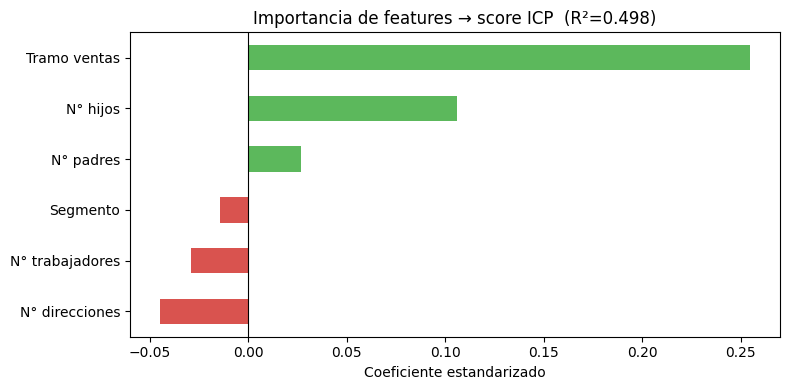


Score promedio predicho por categoría:
                score  score_predicho
origen                               
Cliente           1.0           0.635
Funnel            0.7           0.635
No calificados    0.0           0.562
Random            0.0           0.063


In [ ]:
# ── Regresión ICP sobre df_prueba_total ──────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd

# 1. Target numérico
score_map = {'Cliente': 1.0, 'Funnel': 0.7, 'No calificados': 0.3, 'Random': 0.0}
df_prueba_total_random['score'] = df_prueba_total_random['origen'].map(score_map)

print('Distribución de categorías:')
print(df_prueba_total_random['origen'].value_counts())
print(f'Sin score (categoría no mapeada): {df_prueba_total_random["score"].isna().sum()}')

# 2. Encodear Segmento → numérico
le = LabelEncoder()
df_prueba_total_random['segmento_enc'] = le.fit_transform(
    df_prueba_total_random['Segmento'].fillna('Otro')
)

FEATURES = [
    'Tramo según ventas',
    'Número de trabajadores',
    'segmento_enc',
    'num_addresses',
    'num_hijos',
    'num_padres',
]
LABELS = [
    'Tramo ventas',
    'N° trabajadores',
    'Segmento',
    'N° direcciones',
    'N° hijos',
    'N° padres',
]

df_modelo = df_prueba_total_random[FEATURES + ['score', 'origen']].dropna()
print(f'\nFilas con datos completos: {len(df_modelo)}')

X = df_modelo[FEATURES].astype(float)
y = df_modelo['score']

# 3. Escalar y entrenar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LinearRegression()
model.fit(X_scaled, y)

r2 = model.score(X_scaled, y)
print(f'\nR² = {r2:.3f}')

# 4. Coeficientes
coefs = pd.Series(model.coef_, index=LABELS).sort_values()
print('\nCoeficientes (+ empuja hacia Cliente, - empuja hacia No calificado):')
print(coefs.round(4).to_string())

# 5. Gráfico
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#d9534f' if v < 0 else '#5cb85c' for v in coefs]
coefs.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Importancia de features → score ICP  (R²={r2:.3f})')
ax.set_xlabel('Coeficiente estandarizado')
plt.tight_layout()
plt.show()

# 6. Score promedio por categoría
df_modelo = df_modelo.copy()
df_modelo['score_predicho'] = model.predict(X_scaled).clip(0, 1).round(3)
print('\nScore promedio predicho por categoría:')
print(df_modelo.groupby('origen')[['score', 'score_predicho']].mean().round(3))


Distribución de categorías:
origen
Cliente           28
Funnel            28
No calificados    20
Name: count, dtype: int64
Sin score (categoría no mapeada): 0

Filas con datos completos: 99

R² = 0.067

Coeficientes (+ empuja hacia Cliente, - empuja hacia No calificado):
N° direcciones    -0.0501
N° trabajadores   -0.0417
Segmento           0.0004
Tramo ventas       0.0073
N° padres          0.0146
N° hijos           0.1198


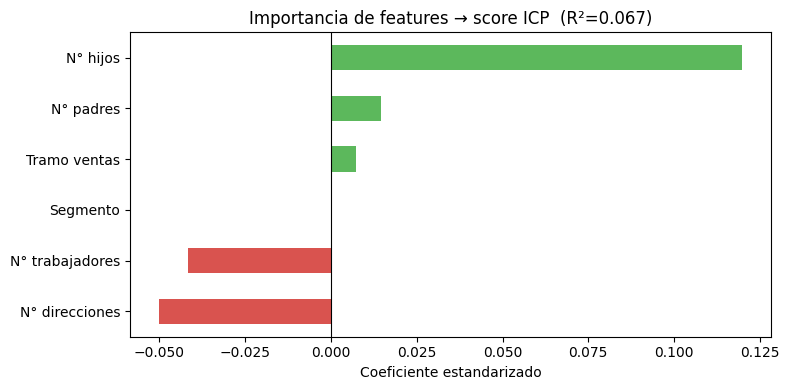


Score promedio predicho por categoría:
                score  score_predicho
origen                               
Cliente           1.0           0.651
Funnel            0.7           0.651
No calificados    0.0           0.587


In [ ]:
# ── Regresión ICP sobre df_prueba_total ──────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd

#saco el financiero:

df_sin_fin = df_prueba_total[df_prueba_total['Segmento'] != 'Financiero'].copy()


# 1. Target numérico
score_map = {'Cliente': 1.0, 'Funnel': 1, 'No calificados': 0.0}
df_sin_fin['score'] = df_sin_fin['origen'].map(score_map)

print('Distribución de categorías:')
print(df_sin_fin['origen'].value_counts())
print(f'Sin score (categoría no mapeada): {df_sin_fin["score"].isna().sum()}')

# 2. Encodear Segmento → numérico
le = LabelEncoder()
df_sin_fin['segmento_enc'] = le.fit_transform(
    df_sin_fin['Segmento'].fillna('Otro')
)

FEATURES = [
    'Tramo según ventas',
    'Número de trabajadores',
    'segmento_enc',
    'num_addresses',
    'num_hijos',
    'num_padres',
]
LABELS = [
    'Tramo ventas',
    'N° trabajadores',
    'Segmento',
    'N° direcciones',
    'N° hijos',
    'N° padres',
]

df_modelo = df_prueba_total[FEATURES + ['score', 'origen']].dropna()
print(f'\nFilas con datos completos: {len(df_modelo)}')

X = df_modelo[FEATURES].astype(float)
y = df_modelo['score']

# 3. Escalar y entrenar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LinearRegression()
model.fit(X_scaled, y)

r2 = model.score(X_scaled, y)
print(f'\nR² = {r2:.3f}')

# 4. Coeficientes
coefs = pd.Series(model.coef_, index=LABELS).sort_values()
print('\nCoeficientes (+ empuja hacia Cliente, - empuja hacia No calificado):')
print(coefs.round(4).to_string())

# 5. Gráfico
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#d9534f' if v < 0 else '#5cb85c' for v in coefs]
coefs.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Importancia de features → score ICP  (R²={r2:.3f})')
ax.set_xlabel('Coeficiente estandarizado')
plt.tight_layout()
plt.show()

# 6. Score promedio por categoría
df_modelo = df_modelo.copy()
df_modelo['score_predicho'] = model.predict(X_scaled).clip(0, 1).round(3)
print('\nScore promedio predicho por categoría:')
print(df_modelo.groupby('origen')[['score', 'score_predicho']].mean().round(3))
